In [1]:
!pip install ~/fwiVis/utility_functions/
! pip install plotnine

Processing /home/jovyan/fwiVis/utility_functions
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'fwiVis' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'fwiVis'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for fwiVis: filename=fwivis-0.1-py3-none-any.whl size=5594 sha256=28db76478b7c88aac2f89aa17902ac3d2a15080c42758b99ca7bec1fe3f0a890
  Stored in directory: /tmp/pip-ephem-wheel-cache-gvolvd3u/wheels/79/0f/3d/08c18473dd7e0fb915900e6b4f13b81f1fa84371f9bf24d864
Successfully built fwiVis
  Attempting uninstall: fwiVis
    Found existing installation: fwiVis 0.1
    Uninstalling fwiVis-0.1:
      Successfully uninstalled fwiVis-0.1


In [2]:
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
#import contextily as cx
from shapely.geometry import box
import sys
from datetime import datetime, timedelta
from itertools import chain

from datetime import date
from bs4 import BeautifulSoup
import requests
import os
import plotnine
import xarray as xr
import ast
import matplotlib.cm as cm
import matplotlib.colors as mc
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
import colorsys
import matplotlib.dates as mdates
import matplotlib as mpl
from matplotlib.ticker import StrMethodFormatter
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d

#import numpy as np
from matplotlib import pyplot as plt
from plotnine import ggplot, geom_point, geom_jitter, aes, stat_smooth, facet_wrap
import plotnine as plotnine
import seaborn as sns
import fwiVis.fwiVis as fv

# Read in Data

In [3]:
fire3 = fv.formatting_read_in("data/Quebec_v3_full_data_perimeters20241112.csv", start_time = '2023-05-31 00:00:00', end_time = '2023-09-15 12:00:00', gen_cols = True, merge_with_ciffc = False, merge_with_nbac = True )

print(f"Using {len(fire3.fireID.unique())} fires for analysis")

/srv/conda/envs/notebook/lib/python3.12/site-packages/fwiVis/fwiVis.py:206: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
Skipping field prov_code: unsupported OGR type: 5
Skipping field prov_name_en: unsupported OGR type: 5
/srv/conda/envs/notebook/lib/python3.12/site-packages/fwiVis/fwiVis.py:235: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/srv/conda/envs/notebook/lib/python3.12/site-packages/fwiVis/fwiVis.py:236: F

Using 160 fires for analysis


# Make DataFrame organized by number of fires spreading, time, and distributions of FWI values

In [4]:
thresh = 1
thresh_relative = 0.05
def get_num_fires(df, thresh = thresh, var = "farea_diff_stand"):
    df.loc[df.is_ig, ["farea_diff_stand"]] = df.loc[df.is_ig, ['farea']].to_numpy()

    n = len(df[df[var] > thresh].fireID.unique())
    return(n)


def get_percent_fires_spread(df, thresh = thresh, var = "farea_diff_stand"): ### note: I am rounding this so that the numbers area easier to think about
    df.loc[df.is_ig, ["farea_diff_stand"]] = df.loc[df.is_ig, ['farea']]
    n = len(df.fireID.unique())
    n_thresh = len(df[df[var] > thresh].fireID.unique())
    if(n == 0):
        print(f"{n} fires on the landscape.")
        return(n)
    return(round(n_thresh/n, 2))
    
num_fires = fire3.groupby("t").apply(get_num_fires).reset_index()
num_fires_rel_growth = fire3.groupby("t").apply(lambda x: get_num_fires(x, thresh = thresh_relative, var = "frac_change")).reset_index()
percent_fires = fire3.groupby("t").apply(get_percent_fires_spread).reset_index()
percent_fires.rename(columns={0 : "percent_fires"})
percent_fires.loc[:,"FWI_spread"] = ""
num_fires.rename(columns={0 : "num_fires"})
num_fires.loc[:,"FWI_spread"] = ""
num_fires_rel_growth.rename(columns={0 : "num_fires"})
num_fires_rel_growth.loc[:, "FWI_spread"] = ""

FWI_var = 'GEOS5_IMERGEARLY'#"GEOS-5.IMERGEARLY" GEOS_IMERGEARLY
#def get_fwi_spread_at_day(df, num_fires = num_fires, FWI_var = "GEOS-5.IMERGEARLY"):
df = fire3.copy()
df = df[["t", "fireID", FWI_var]].drop_duplicates()
for t in num_fires.t:
    fwi_vals = df[df.t == t].groupby("fireID")[FWI_var].max() ## Should only be one value
    counts = df[df.t == t].groupby("fireID")[FWI_var].count().reset_index()
    if(any(counts[FWI_var] > 1)):
        print(f"Multiple FWI value for specific date \n {counts[counts[FWI_var] >1]}")
    tmp = fwi_vals.agg(list)
    num_fires.loc[num_fires.t == t, "FWI_spread"] =  str(tmp)

df = fire3.copy()
df = df[["t", "fireID", FWI_var]].drop_duplicates()
for t in percent_fires.t:
    fwi_vals = df[df.t == t].groupby("fireID")[FWI_var].max() ## Should only be one value
    counts = df[df.t == t].groupby("fireID")[FWI_var].count().reset_index()
    if(any(counts[FWI_var] > 1)):
        print(f"Multiple FWI value for specific date \n {counts[counts[FWI_var] >1]}")
    tmp = fwi_vals.agg(list)
    percent_fires.loc[percent_fires.t == t, "FWI_spread"] =  str(tmp)


df = fire3.copy()
df = df[["t", "fireID", FWI_var]].drop_duplicates()
for t in num_fires_rel_growth.t:
    fwi_vals = df[df.t == t].groupby("fireID")[FWI_var].max() ## Should only be one value
    counts = df[df.t == t].groupby("fireID")[FWI_var].count().reset_index()
    if(any(counts[FWI_var] > 1)):
        print(f"Multiple FWI value for specific date \n {counts[counts[FWI_var] >1]}")
    tmp = fwi_vals.agg(list)
    num_fires_rel_growth.loc[num_fires_rel_growth.t == t, "FWI_spread"] =  str(tmp)

# Convert to a list of actual Python lists
converted_lists = [ast.literal_eval(x) for x in num_fires['FWI_spread']]
flattened_list = [item for sublist in converted_lists for item in sublist]


def condense_by_num_fires_spreading(df):

     #actual_list = [float(x) for x in df[df.t == t].FWI_spread.strip('[]').split(',')
    converted_lists = [ast.literal_eval(x) for x in df['FWI_spread']]
    flattened_list = [item for sublist in converted_lists for item in sublist]

    df.loc[:, "max_fwi"] =  np.max(flattened_list)
    df.loc[:, "min_fwi"] = np.min(flattened_list)
    df.loc[:, "mean_fwi"] = np.mean(flattened_list)
    df.loc[:, "all_vals"] = str(flattened_list)
    df.loc[:, "75_percent"] = np.quantile(flattened_list, 0.75)
    df.loc[:, "25_percent"] = np.quantile(flattened_list, 0.25)
    df.loc[:, "975_percent"] = np.quantile(flattened_list, 0.975)
    df.loc[:, "025_percent"] = np.quantile(flattened_list, 0.025)

    return(df)
    

def num_fires_spreading_FWI_vals(df):

     #actual_list = [float(x) for x in df[df.t == t].FWI_spread.strip('[]').split(',')
    converted_lists = [ast.literal_eval(x) for x in df['FWI_spread']]
    flattened_list = [item for sublist in converted_lists for item in sublist]

    return(flattened_list)

def num_fires_spreading_long_df(df):

     #actual_list = [float(x) for x in df[df.t == t].FWI_spread.strip('[]').split(',')
    converted_lists = [ast.literal_eval(x) for x in df['FWI_spread']]
    flattened_list = [item for sublist in converted_lists for item in sublist]
    new_df = pd.DataFrame({"FWI_spread": flattened_list, 
                            })
    new_df.loc[:, "num_fires"] = df[0]

    return(new_df)
    

    
        
num_test = num_fires.copy()

num_test = num_test.groupby(0).apply(condense_by_num_fires_spreading)

num_test = num_test[[0, "max_fwi", 'mean_fwi', 'min_fwi', "025_percent", "975_percent", "25_percent", "75_percent"]].drop_duplicates()
num_test = num_test.rename(columns = {0: "num_fires"})
vals = num_fires.groupby(0).t.count()
num_test["day_count"] = ""
#num_test["day_count"] = num_test["day_count"].map(vals)
num_test["day_count"] = vals.values


percent_test = percent_fires.copy()
percent_test = percent_test.groupby(0).apply(condense_by_num_fires_spreading)

percent_test = percent_test[[0, "max_fwi", 'mean_fwi', 'min_fwi', "025_percent", "975_percent", "25_percent", "75_percent"]].drop_duplicates()
percent_test = percent_test.rename(columns = {0: "percent_fires"})
vals = percent_fires.groupby(0).t.count()
percent_test["day_count"] = ""
percent_test["day_count"] = vals.values

percent_test_sm = percent_fires.copy()
percent_test_sm[0] = percent_test_sm[0].round(1)
percent_test_sm = percent_test_sm.groupby(0).apply(condense_by_num_fires_spreading).reset_index(drop = True)
percent_fires_rn = percent_fires.copy()
percent_fires_rn[0] = percent_fires_rn[0].round(1)
vals = percent_fires_rn.groupby(0).t.count()


percent_test_sm = percent_test_sm[[0, "max_fwi", 'mean_fwi', 'min_fwi', "025_percent", "975_percent", "25_percent", "75_percent"]].drop_duplicates()
percent_test_sm = percent_test_sm.rename(columns = {0: "percent_fires"})
percent_test_sm["day_count"] = ""
#percent_test_sm["day_count"] = percent_test_sm["day_count"].map(vals)
percent_test_sm["day_count"] = vals.values


num_fires_rel_growth_test  = num_fires_rel_growth.copy()
num_fires_rel_growth_test = num_fires_rel_growth_test.groupby(0).apply(condense_by_num_fires_spreading)
num_fires_rel_growth_test = num_fires_rel_growth_test[[0, "max_fwi", 'mean_fwi', 'min_fwi', "025_percent", "975_percent", "25_percent", "75_percent"]].drop_duplicates()
num_fires_rel_growth_test = num_fires_rel_growth_test.rename(columns = {0: "num_fires"})
vals = num_fires_rel_growth.groupby(0).t.count()
num_fires_rel_growth_test["day_count"] = ""
num_fires_rel_growth_test["day_count"] = vals.values

/tmp/ipykernel_3361/2959074603.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_3361/2959074603.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_3361/2959074603.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_grou

In [5]:
## Merge both df's together to get the dates tied to a specific # of fires and vice versa
num_fires = num_fires.rename(columns = {0: "num_fires"})
percent_fires = percent_fires.rename(columns = {0: "percent_fires"})

#percent_test = percent_test.reset_index()
#percent_test = percent_test.rename(columns = {0: "num_fires"})


num_merge = num_test.reset_index(drop = True).merge(num_fires.reset_index(drop = True), on = "num_fires" )
percent_merge = percent_test.reset_index(drop = True).merge(percent_fires.reset_index(drop = True), on = "percent_fires")


counts = num_merge.day_count
categories = num_merge.num_fires

pcounts = percent_merge.day_count
pcategories = percent_merge.percent_fires

tmin = num_merge.t.astype("datetime64[ns]").min()
num_merge[f"days_since"] = num_merge.t.astype("datetime64[ns]") - tmin
percent_merge[f"days_since"] = percent_merge.t.astype("datetime64[ns]") - tmin

num_merge[f"days_since_{tmin}"] = num_merge[f"days_since"].dt.days
percent_merge[f"days_since_{tmin}"] = percent_merge[f"days_since"].dt.days

qualities = num_merge[f"days_since_{tmin}"].astype("int")#num_merge.t.astype("datetime64[ns]").dt.hours()
pqualities = percent_merge[f"days_since_{tmin}"].astype("int")


# Set up color maps for figures

In [6]:
# Retrieve the original colormap
original_cmap = plt.get_cmap('spring_r')

def create_darker_colormap(base_cmap_name, darkness_factor):
    """
    Create a darker version of a given colormap.
    
    Parameters:
    - base_cmap_name: str, the name of the base colormap.
    - darkness_factor: float, a factor between 0 and 1 to darken the colormap.
                       1 means no change, 0 means completely dark.
    
    Returns:
    - LinearSegmentedColormap: a new colormap that is a darker version of the base colormap.
    """
    # Retrieve the original colormap
    base_cmap = plt.get_cmap(base_cmap_name)
    
    # Create a list of colors from the colormap and darken them
    colors = base_cmap(np.linspace(0, 1, 256))
    colors[:, :3] *= darkness_factor
    colors = np.clip(colors, 0, 1)  # Ensure values are within [0, 1]
    
    # Create the new colormap
    return LinearSegmentedColormap.from_list(f"{base_cmap_name}_darker", colors)

def darken_color(color, scale):
    """Darkens a color by scaling its lightness in HLS space.

    Args:
        color: An RGB tuple, hex code, or color name.
        scale: A value between 0 and 1 to scale the lightness (0 is black, 1 is no change).

    Returns:
        A darkened color in RGB tuple format.
    """
    
    rgb = mc.to_rgb(color)
    hls = colorsys.rgb_to_hls(*rgb)
    new_lightness = hls[1] * scale
    new_rgb = colorsys.hls_to_rgb(hls[0], new_lightness, hls[2])
    return new_rgb
    

# Define the darkness factor (between 0 and 1)
darkness_factor = 0.85

# Create a custom colormap with the specified darkness factor
darker_cmap = create_darker_colormap('spring_r', darkness_factor)

# Create Plots

The number of days with 0 fires is [27]


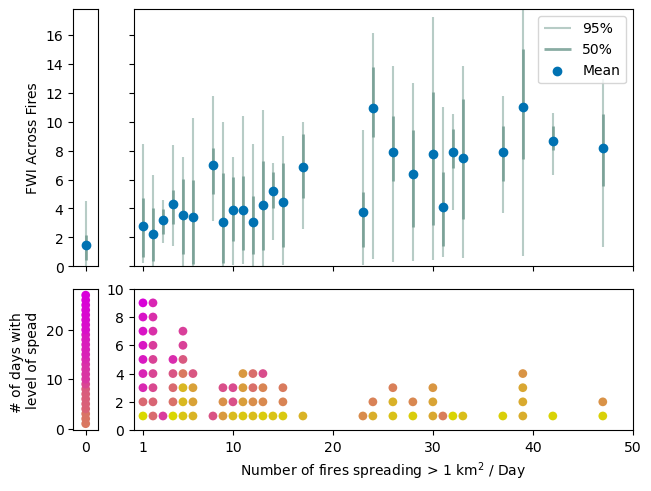

In [7]:
### Try without zeros

## combining both plots


df = num_merge[['num_fires','day_count',f'days_since_{tmin}']]

# Correct aggregation: take the first count for each category (since they're repeated)
df_agg = df.groupby('num_fires').agg({'day_count': 'first', f'days_since_{tmin}': list}).reset_index()
max_count = df_agg['day_count'].max()


#fig1, ([ax, ax2],  [ax5, ax6], [ax3, ax4]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,5, 1]}, constrained_layout=True)
fig, ([ ax3, ax], [ax4, ax2]) = plt.subplots(2, 2, gridspec_kw={ 'height_ratios': [10,5.5], 'width_ratios':[1, 20]}, constrained_layout=True) # 


# Plot the data on the axes
point_color = "#0072B2"
line_color = "#87ABA1"
dark_line_color = darken_color(line_color, scale = darkness_factor)

no_zero_con = num_test.num_fires > 0
zero_con = num_test.num_fires == 0

ax.vlines(x = num_test[no_zero_con].num_fires, ymin =num_test.loc[no_zero_con, '025_percent'], ymax = num_test.loc[no_zero_con,'975_percent'], alpha = 0.6, color = line_color, label = "95%", zorder = 1)
ax.vlines(x = num_test[no_zero_con].num_fires, ymin =num_test.loc[no_zero_con,'25_percent'], ymax = num_test.loc[no_zero_con,'75_percent'], alpha = 0.8, linewidth=2, color = dark_line_color, label = "50%", zorder = 2)
ax.scatter(x = num_test[no_zero_con].num_fires, y = num_test[no_zero_con].mean_fwi, label = "Mean", color = point_color, zorder = 3)
ax.legend()

ax3.vlines(x = num_test[zero_con].num_fires, ymin =num_test.loc[zero_con, '025_percent'], ymax = num_test.loc[zero_con,'975_percent'], alpha = 0.6, color = line_color, label = "95%", zorder = 1)
ax3.vlines(x = num_test[zero_con].num_fires, ymin =num_test.loc[zero_con,'25_percent'], ymax = num_test.loc[zero_con,'75_percent'], alpha = 0.8, linewidth=2, color = dark_line_color, label = "50%", zorder = 2)
ax3.scatter(x = num_test[zero_con].num_fires, y = num_test[zero_con].mean_fwi, label = "Mean", color = point_color, zorder = 3)
ax3.set_ylim(bottom = 0, top = num_test['975_percent'].max())
#ax3.set_xlim(left = -1, right = 1)

ax.sharex(ax2)  # Left column shares x-axis
ax.sharey(ax3)
ax3.sharex(ax4)  # Right column shares x-axis

#ax.set_xticklabels([])
#ax3.set_xticklabels([])

#ax.set_yticklabels([])
#ax2.set_yticklabels([])

ax.tick_params(labelbottom=False)  # Hide x labels in shared axis 
ax3.tick_params(labelbottom=False)
ax.tick_params(labelleft=False)  



# Set the title of the plot
ax.set_title("")

# Set the labels for the x and y axes
ax3.set_ylabel("FWI Across Fires")


#### Dot plot
# ax2.barh(num_test.num_fires, num_test.day_count)
# #ax2.set_yscale("log")
# ax2.set_xlabel("# of days with \nlevel of spead")
# #ax2.xaxis.set_visible(False)
point_size = (1 / max_count) * ax2.get_window_extent().height * 9
# for i, row in df_agg.iterrows():
#     category = row['num_fires']
#     count = row['day_count']
#     qualities = row[f'days_since_{tmin}']
    
#     y = [i] * count
#     #y = category
#     x = np.arange(count)
    
#     scatter = ax2.scatter(x, y, c=qualities[:count], cmap='viridis', s=point_size*0.7, edgecolor='none')
cmap = cm.spring_r
norm = plt.Normalize(0, df[f'days_since_{tmin}'].max())

for category, group in df[df.num_fires > 0].groupby('num_fires'):
    count = group['day_count'].iloc[0]
    qualities = group[f'days_since_{tmin}'].tolist()
    y_value = category #group['num_fires'].iloc[0]  # Assuming you have a 'y_value' column that matches your scatter plot
    #print(str(y_value) + " : Number of fires")
    #print(str(qualities) + ": days since")
    x = np.arange(count) + 1
    y = [y_value] * count
    
    ax2.scatter(y, x, c=qualities, cmap=darker_cmap, norm = norm, s=point_size, edgecolor='none') # 'spring_r' # qualities[:count]
    
for category, group in df[df.num_fires <= 0].groupby('num_fires'):
    count1 = group['day_count'].iloc[0]
    qualities1 = group[f'days_since_{tmin}'].tolist()
    y_value1 = category #group['num_fires'].iloc[0]  # Assuming you have a 'y_value' column that matches your scatter plot
    #print(str(y_value) + " : Number of fires")
    #print(str(qualities) + ": days since")
    x1 = np.arange(count1) + 1
    y1 = [y_value1] * count1
    
    ax4.scatter(y1, x1, c=qualities1, cmap=darker_cmap, norm = norm, s=point_size, edgecolor='none') # 'spring_r' # qualities[:count]

    #ax2.set_xlim(xmin = -2)
# categories = df['num_fires'].unique()
# ax2.set_yticks(range(len(categories)))
#ax2.set_y=yticks(range(len(df_agg)))
#ax.set_xticklabels(df_agg['num_fires'])
ax4.set_ylabel("# of days with \nlevel of spead")
ax2.set_ylim(bottom = 0)
ax2.set_ylim(top = 10)
ax2.set_xlim(left = 0.1) # Can't be zero, but 1 will cut off the blurbs
current_ticks = list(ax2.get_xticks())
current_ticks.append(1)
current_ticks = current_ticks[1:]
current_ticks = sorted(set(current_ticks))  # Remove duplicates and sort
ax2.set_xticks(current_ticks)

ax4.set_xticks([0])

ax2.set_xlabel(f"Number of fires spreading > {thresh} km$^2$ / Day")
# cbar = plt.colorbar(ax2)
# cbar.set_label('Days Past 5/31')
sm =  ScalarMappable(norm=norm, cmap = darker_cmap)
#cbar = fig.colorbar(sm, ax = ax2, label = f"Days Since Start of Fire Season",  orientation='horizontal') #  orientation='horizontal'
plt.savefig(f"some_figs/fires_spread_fwi_distribution/break_y_axis_reverse_axis_no_zeros_cbar_with_dots_number_fires_spread_{thresh}.png")
print(f"The number of days with 0 fires is {df[df.num_fires == 0].day_count.unique()}")
plt.show()

The number of days with 0 fires is [30]


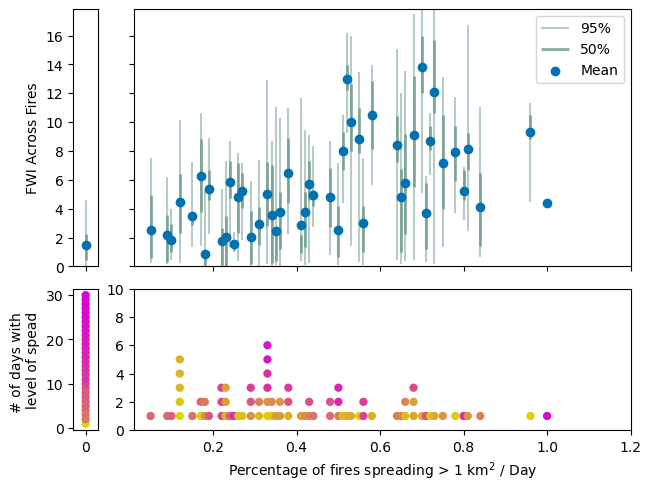

In [8]:
### Percentage

## combining both plots


df = percent_merge[['percent_fires','day_count',f'days_since_{tmin}']]

# Correct aggregation: take the first count for each category (since they're repeated)
df_agg = df.groupby('percent_fires').agg({'day_count': 'first', f'days_since_{tmin}': list}).reset_index()
max_count = df_agg['day_count'].max()


#fig1, ([ax, ax2],  [ax5, ax6], [ax3, ax4]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,5, 1]}, constrained_layout=True)
fig, ([ ax3, ax], [ax4, ax2]) = plt.subplots(2, 2, gridspec_kw={ 'height_ratios': [10,5.5], 'width_ratios':[1, 20]}, constrained_layout=True) # 


# Plot the data on the axes
point_color = "#0072B2"
line_color = "#87ABA1"
dark_line_color = darken_color(line_color, scale = darkness_factor)

no_zero_con = percent_test.percent_fires > 0
zero_con = percent_test.percent_fires == 0

ax.vlines(x = percent_test[no_zero_con].percent_fires, ymin =percent_test.loc[no_zero_con, '025_percent'], ymax = percent_test.loc[no_zero_con,'975_percent'], alpha = 0.6, color = line_color, label = "95%", zorder = 1)
ax.vlines(x = percent_test[no_zero_con].percent_fires, ymin =percent_test.loc[no_zero_con,'25_percent'], ymax = percent_test.loc[no_zero_con,'75_percent'], alpha = 0.8, linewidth=2, color = dark_line_color, label = "50%", zorder = 2)
ax.scatter(x = percent_test[no_zero_con].percent_fires, y = percent_test[no_zero_con].mean_fwi, label = "Mean", color = point_color, zorder = 3)
ax.legend()

ax3.vlines(x = percent_test[zero_con].percent_fires, ymin =percent_test.loc[zero_con, '025_percent'], ymax = percent_test.loc[zero_con,'975_percent'], alpha = 0.6, color = line_color, label = "95%", zorder = 1)
ax3.vlines(x = percent_test[zero_con].percent_fires, ymin =percent_test.loc[zero_con,'25_percent'], ymax = percent_test.loc[zero_con,'75_percent'], alpha = 0.8, linewidth=2, color = dark_line_color, label = "50%", zorder = 2)
ax3.scatter(x = percent_test[zero_con].percent_fires, y = percent_test[zero_con].mean_fwi, label = "Mean", color = point_color, zorder = 3)
ax3.set_ylim(bottom = 0, top = percent_test['975_percent'].max())
#ax3.set_xlim(left = -1, right = 1)

ax.sharex(ax2)  # Left column shares x-axis
ax.sharey(ax3)
ax3.sharex(ax4)  # Right column shares x-axis

#ax.set_xticklabels([])
#ax3.set_xticklabels([])

#ax.set_yticklabels([])
#ax2.set_yticklabels([])

ax.tick_params(labelbottom=False)  # Hide x labels in shared axis 
ax3.tick_params(labelbottom=False)
ax.tick_params(labelleft=False)  



# Set the title of the plot
ax.set_title("")

# Set the labels for the x and y axes
ax3.set_ylabel("FWI Across Fires")


#### Dot plot
# ax2.barh(percent_test.percent_fires, percent_test.day_count)
# #ax2.set_yscale("log")
# ax2.set_xlabel("# of days with \nlevel of spead")
# #ax2.xaxis.set_visible(False)
point_size = (1 / max_count) * ax2.get_window_extent().height * 9
# for i, row in df_agg.iterrows():
#     category = row['percent_fires']
#     count = row['day_count']
#     qualities = row[f'days_since_{tmin}']
    
#     y = [i] * count
#     #y = category
#     x = np.arange(count)
    
#     scatter = ax2.scatter(x, y, c=qualities[:count], cmap='viridis', s=point_size*0.7, edgecolor='none')
cmap = cm.spring_r
norm = plt.Normalize(0, df[f'days_since_{tmin}'].max())

for category, group in df[df.percent_fires > 0].groupby('percent_fires'):
    count = group['day_count'].iloc[0]
    qualities = group[f'days_since_{tmin}'].tolist()
    y_value = category #group['percent_fires'].iloc[0]  # Assuming you have a 'y_value' column that matches your scatter plot

    #print(str(qualities) + ": days since")
    x = np.arange(count) + 1
    y = [y_value] * count
    
    ax2.scatter(y, x, c=qualities, cmap=darker_cmap, norm = norm, s=point_size, edgecolor='none') # 'spring_r' # qualities[:count]
    
for category, group in df[df.percent_fires <= 0].groupby('percent_fires'):
    count1 = group['day_count'].iloc[0]
    qualities1 = group[f'days_since_{tmin}'].tolist()
    y_value1 = category #group['percent_fires'].iloc[0]  # Assuming you have a 'y_value' column that matches your scatter plot
    #print(str(y_value) + " : percentber of fires")
    #print(str(qualities) + ": days since")
    x1 = np.arange(count1) + 1
    y1 = [y_value1] * count1
    
    ax4.scatter(y1, x1, c=qualities1, cmap=darker_cmap, norm = norm, s=point_size, edgecolor='none') # 'spring_r' # qualities[:count]

    #ax2.set_xlim(xmin = -2)
# categories = df['percent_fires'].unique()
# ax2.set_yticks(range(len(categories)))
#ax2.set_y=yticks(range(len(df_agg)))
#ax.set_xticklabels(df_agg['percent_fires'])
ax4.set_ylabel("# of days with \nlevel of spead")
ax2.set_ylim(bottom = 0)
ax2.set_ylim(top = 10)
ax2.set_xlim(left = 0.01) # Can't be zero, but 1 will cut off the blurbs
current_ticks = list(ax2.get_xticks())
current_ticks.append(1)
current_ticks = current_ticks[1:]
current_ticks = sorted(set(current_ticks))  # Remove duplicates and sort
ax2.set_xticks(current_ticks)

ax4.set_xticks([0])

ax2.set_xlabel(f"Percentage of fires spreading > {thresh} km$^2$ / Day")
# cbar = plt.colorbar(ax2)
# cbar.set_label('Days Past 5/31')
sm =  ScalarMappable(norm=norm, cmap = darker_cmap)
#cbar = fig.colorbar(sm, ax = ax2, label = f"Days Since Start of Fire Season",  orientation='horizontal') #  orientation='horizontal'
plt.savefig(f"some_figs/fires_spread_fwi_distribution/break_y_axis_reverse_axis_no_zeros_cbar_with_dots_percent_fires_spread_{thresh}.png")
print(f"The number of days with 0 fires is {df[df.percent_fires == 0].day_count.unique()}")
plt.show()

# Text for results

In [9]:
print(f"There were a total of {len( num_merge[ num_merge.num_fires >= 1].t.unique())} days during the 2023 fire season in Quebec when at least one fire spread >1 km2, of the {len(num_merge.t.unique())} total days.")
print(f"There were a total of {len( num_merge[ num_merge.num_fires == 0].t.unique())} days during the 2023 fire season in Quebec when no fires were spreading of the {len(num_merge.t.unique())} total days.")
print(f"including the day with the largest number of fires spreading >1 km2 (n = { num_merge.num_fires.max()}), on {num_merge[num_merge.num_fires == num_merge.num_fires.max()].t.iloc[0]}")


cut_off = 7
ucut_off = 20
print(f"Days with {0} or fewer fires were the most common {len( num_merge[ num_merge.num_fires <= 0 ].t.unique())}, and mean FWI was less than {num_merge[ num_merge.num_fires <= 0 ].mean_fwi.max()}")


print(f"Days with {1} - {cut_off} fire spreading {len( num_merge[ (num_merge.num_fires > 0) & (num_merge.num_fires <= cut_off) ].t.unique())}, and mean FWI was less than {num_merge[ (num_merge.num_fires > 0) & (num_merge.num_fires <= cut_off) ].mean_fwi.max()}, amd more than {num_merge[ (num_merge.num_fires > cut_off) & (num_merge.num_fires <= ucut_off) ].mean_fwi.min()} ")



print(f"Days with {cut_off} - {ucut_off} fire spreading {len( num_merge[ (num_merge.num_fires > cut_off) & (num_merge.num_fires <= ucut_off) ].t.unique())}, and mean FWI was less than {num_merge[ (num_merge.num_fires > cut_off) & (num_merge.num_fires <= ucut_off) ].mean_fwi.max()}, amd more than {num_merge[ (num_merge.num_fires > cut_off) & (num_merge.num_fires <= ucut_off) ].mean_fwi.min()} ")


print(f"Days with {cut_off} - {ucut_off} fire spreading {len( num_merge[(num_merge.num_fires > ucut_off) ].t.unique())}, and mean FWI was less than {num_merge[(num_merge.num_fires > ucut_off) ].mean_fwi.max()}, amd more than {num_merge[(num_merge.num_fires > ucut_off) ].mean_fwi.min()} ")


There were a total of 81 days during the 2023 fire season in Quebec when at least one fire spread >1 km2, of the 108 total days.
There were a total of 27 days during the 2023 fire season in Quebec when no fires were spreading of the 108 total days.
including the day with the largest number of fires spreading >1 km2 (n = 47), on 2023-06-04 12:00:00
Days with 0 or fewer fires were the most common 27, and mean FWI was less than 1.4691632554834964
Days with 1 - 7 fire spreading 35, and mean FWI was less than 4.3166402903421766, amd more than 3.043296541696763 
Days with 7 - 20 fire spreading 24, and mean FWI was less than 7.0285617995387515, amd more than 3.043296541696763 
Days with 7 - 20 fire spreading 22, and mean FWI was less than 11.029570681115915, amd more than 3.7533660674480847 


In [10]:
def get_num_spread_days_per_fire(df,  var = "farea_diff_stand"):
        df.loc[df.is_ig, ["farea_diff_stand"]] = df.loc[df.is_ig, ['farea']].to_numpy()

        t_spread = len(df[df[var] > thresh].t.unique())
        t_non_spread = len(df[df[var] <= thresh].t.unique())
        return(pd.DataFrame({"t_spread": [t_spread], "t_non_spread": [t_non_spread]} ))

pf_num_spread = fire3.groupby("fireID").apply(get_num_spread_days_per_fire)
print(f" Most fires had {np.mean(pf_num_spread.t_spread/ (pf_num_spread.t_spread + pf_num_spread.t_non_spread))} percent spread days on average, ( var {np.var(pf_num_spread.t_spread/ (pf_num_spread.t_spread + pf_num_spread.t_non_spread))})")

total_fire_days = np.sum(pf_num_spread.t_spread + pf_num_spread.t_non_spread)
print(f" We tracked {total_fire_days} days across {len(pf_num_spread.index.unique())} fires. Of those days, {sum(pf_num_spread.t_spread) / total_fire_days} percent had >1km^2 spread. ")

 Most fires had 0.5463390357238233 percent spread days on average, ( var 0.07846728723593606)
 We tracked 2530 days across 160 fires. Of those days, 0.44031620553359685 percent had >1km^2 spread. 


/tmp/ipykernel_3361/2377071455.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


# Checking the percentage of growth during spread days

In [12]:
# June 3-9, June 12-13th, June 20-26, 

j39 = (fire3.t >= "2023-06-3 00:00:00") & (fire3.t <= "2023-06-9 12:00:00")
j1213 = (fire3.t >= "2023-06-12 00:00:00") & (fire3.t <= "2023-06-13 12:00:00")
j2026 = (fire3.t >= "2023-06-20 00:00:00") & (fire3.t <= "2023-06-26 12:00:00")

total_farea = fire3.groupby("fireID").farea.max()
total_farea = total_farea.sum()
print(total_farea)


fire3_subset = fire3[j39 | j1213 | j2026]
fs = fire3_subset.groupby("fireID").farea_diff_stand.sum()

print(fs.sum()/total_farea) ## Fraction of area during the above periods.


fr_growth = fire3[fire3.spread_bool_100 == True]

fr_growth.groupby("fireID").farea_diff_stand.sum().sum()/total_farea

50072.46504302653
0.5555318109551677


np.float64(0.9800272467736724)